In [1]:
import numpy as np
import pandas as pd

In [2]:
import sys
sys.path.append(r"/")

from provenance_coo import Provenance, trace

# Datasets 

In [3]:
# Example datasets
user_df = pd.DataFrame({
    "ID": [10, 20, 30, 40],
    "Birthdate": ["1996-07-12", "1994-03-08", np.nan, "1987-11-23"],
    "Gender": ["F", "M", "F", "M"],
    "Postcode": ["90210", np.nan, "12345", "67890"]
})

post_df = pd.DataFrame({
    "ID": [1, 2, 3, 4],
    "UID": [10, 40, 30, 10],
    "Topic": ["Art", "Football", "Travel", "Travel"]
})

# Subscribe
prov = Provenance(save_dir="example_results", verbose=1)
user_wdf = prov.subscribe(user_df)
post_wdf = prov.subscribe(post_df)

display(user_wdf)
display(post_wdf)

,ID,Birthdate,Gender,Postcode
0,10,1996-07-12,F,90210
1,20,1994-03-08,M,NaN
2,30,NaN,F,12345
3,40,1987-11-23,M,67890


,ID,UID,Topic
0,1,10,Art
1,2,40,Football
2,3,30,Travel
3,4,10,Travel


# Capture

In [4]:
# Add records and reorder
prov.pause()
user_wdf_HA = user_wdf.copy()
user_wdf_HA.loc[len(user_wdf_HA)] = [15, "2000-10-20", "F", "75014"]
user_wdf_HA = user_wdf_HA.sort_values(by="ID")
prov.start()
user_wdf.set(user_wdf_HA)

-- id_in -> id_out--
 1 -> 5
-- df_in: 1 --
    ID   Birthdate Gender Postcode
0  10  1996-07-12      F    90210
1  20  1994-03-08      M      NaN
2  30         NaN      F    12345
3  40  1987-11-23      M    67890
-- df_out: 5 --
    ID   Birthdate Gender Postcode
0  10  1996-07-12      F    90210
4  15  2000-10-20      F    75014
1  20  1994-03-08      M      NaN
2  30         NaN      F    12345
3  40  1987-11-23      M    67890
-- tensor_record --
 [[0 0]
 [2 1]
 [3 2]
 [4 3]]
-- tensor_attr --
 [[0 0]
 [1 1]
 [2 2]
 [3 3]]


In [5]:
# Label Encoding
user_wdf["Gender"] = user_wdf["Gender"].map({"F": 0, "M": 1})

-- id_in -> id_out--
 5 -> 6
-- df_in: 5 --
    ID   Birthdate Gender Postcode
0  10  1996-07-12      F    90210
4  15  2000-10-20      F    75014
1  20  1994-03-08      M      NaN
2  30         NaN      F    12345
3  40  1987-11-23      M    67890
-- df_out: 6 --
    ID   Birthdate  Gender Postcode
0  10  1996-07-12       0    90210
4  15  2000-10-20       0    75014
1  20  1994-03-08       1      NaN
2  30         NaN       0    12345
3  40  1987-11-23       1    67890
-- tensor_record --
 [[0 0]
 [1 1]
 [2 2]
 [3 3]
 [4 4]]
-- tensor_attr --
 [[0 0]
 [1 1]
 [2 2]
 [3 3]]


In [6]:
# Split BirthDate to Year, Month, Day.
prov.pause()
user_wdf_VA = user_wdf.copy()
user_wdf_VA["Birthdate"] = pd.to_datetime(user_wdf_VA["Birthdate"])
user_wdf_VA["Year"] = user_wdf_VA["Birthdate"].dt.year
user_wdf_VA["Month"] = user_wdf_VA["Birthdate"].dt.month
user_wdf_VA["Day"] = user_wdf_VA["Birthdate"].dt.day
column_mapping = {
    "Birthdate": ["Year", "Month", "Day"]
}
prov.start()
prov.capture(user_wdf, user_wdf_VA, column_mapping=column_mapping)

-- id_in -> id_out--
 6 -> 11
-- df_in: 6 --
    ID   Birthdate  Gender Postcode
0  10  1996-07-12       0    90210
4  15  2000-10-20       0    75014
1  20  1994-03-08       1      NaN
2  30         NaN       0    12345
3  40  1987-11-23       1    67890
-- df_out: 11 --
    ID  Birthdate  Gender Postcode    Year  Month   Day
0  10 1996-07-12       0    90210  1996.0    7.0  12.0
4  15 2000-10-20       0    75014  2000.0   10.0  20.0
1  20 1994-03-08       1      NaN  1994.0    3.0   8.0
2  30        NaT       0    12345     NaN    NaN   NaN
3  40 1987-11-23       1    67890  1987.0   11.0  23.0
-- tensor_record --
 [[0 0]
 [1 1]
 [2 2]
 [3 3]
 [4 4]]
-- tensor_attr --
 [[0 0]
 [1 1]
 [2 2]
 [3 3]
 [4 1]
 [5 1]
 [6 1]]


(<COOrdinate sparse matrix of dtype 'int8'
 	with 5 stored elements and shape (5, 5)>,
 <COOrdinate sparse matrix of dtype 'int8'
 	with 7 stored elements and shape (7, 4)>)

In [7]:
# Select columns and reorder
user_wdf_VR = user_wdf_VA[["ID", "Year", "Gender"]]

-- id_in -> id_out--
 11 -> 12
-- df_in: 11 --
    ID  Birthdate  Gender Postcode    Year  Month   Day
0  10 1996-07-12       0    90210  1996.0    7.0  12.0
4  15 2000-10-20       0    75014  2000.0   10.0  20.0
1  20 1994-03-08       1      NaN  1994.0    3.0   8.0
2  30        NaT       0    12345     NaN    NaN   NaN
3  40 1987-11-23       1    67890  1987.0   11.0  23.0
-- df_out: 12 --
    ID    Year  Gender
0  10  1996.0       0
4  15  2000.0       0
1  20  1994.0       1
2  30     NaN       0
3  40  1987.0       1
-- tensor_record --
 [[0 0]
 [1 1]
 [2 2]
 [3 3]
 [4 4]]
-- tensor_attr --
 [[0 0]
 [1 4]
 [2 2]]


In [8]:
join_wdf = user_wdf_VR.merge(post_wdf, left_on="ID", right_on="UID", how="inner")

-- id_in -> id_out--
 12 -> 13
-- df_in: 12 --
    ID    Year  Gender
0  10  1996.0       0
4  15  2000.0       0
1  20  1994.0       1
2  30     NaN       0
3  40  1987.0       1
-- df_out: 13 --
    ID_x    Year  Gender  ID_y  UID     Topic
0    10  1996.0       0     1   10       Art
1    10  1996.0       0     4   10    Travel
2    30     NaN       0     3   30    Travel
3    40  1987.0       1     2   40  Football
-- tensor_record --
 [[0 0]
 [1 0]
 [2 3]
 [3 4]]
-- tensor_attr --
 [[0 0]
 [1 1]
 [2 2]]
-- id_in -> id_out--
 2 -> 13
-- df_in: 2 --
    ID  UID     Topic
0   1   10       Art
1   2   40  Football
2   3   30    Travel
3   4   10    Travel
-- df_out: 13 --
    ID_x    Year  Gender  ID_y  UID     Topic
0    10  1996.0       0     1   10       Art
1    10  1996.0       0     4   10    Travel
2    30     NaN       0     3   30    Travel
3    40  1987.0       1     2   40  Football
-- tensor_record --
 [[0 0]
 [1 3]
 [2 2]
 [3 1]]
-- tensor_attr --
 [[3 0]
 [4 1]
 [5 2]]


In [9]:
join_wdf = join_wdf.dropna()

-- id_in -> id_out--
 13 -> 14
-- df_in: 13 --
    ID_x    Year  Gender  ID_y  UID     Topic
0    10  1996.0       0     1   10       Art
1    10  1996.0       0     4   10    Travel
2    30     NaN       0     3   30    Travel
3    40  1987.0       1     2   40  Football
-- df_out: 14 --
    ID_x    Year  Gender  ID_y  UID     Topic
0    10  1996.0       0     1   10       Art
1    10  1996.0       0     4   10    Travel
3    40  1987.0       1     2   40  Football
-- tensor_record --
 [[0 0]
 [1 1]
 [2 3]]
-- tensor_attr --
 [[0 0]
 [1 1]
 [2 2]
 [3 3]
 [4 4]
 [5 5]]


# Trace

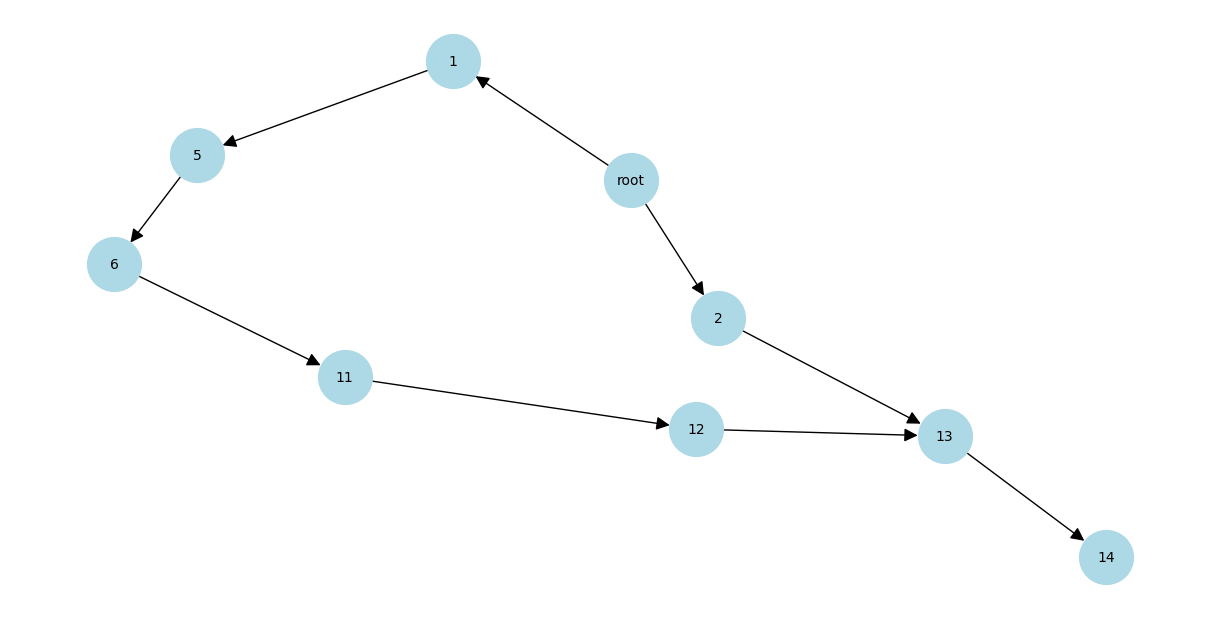

In [10]:
prov.graph.visualize(seed=13)

In [11]:
path = prov.graph.get_edges(1, 14)[0]
tensor_records = [p[0] for p in path]
tensor_attrs = [p[1] for p in path]

In [12]:
# trace record
for direction in ["backward", "forward"]:
    print(f"-- {direction} --")
    trace_record = trace(tensor_records, direction)
    print("-- trace_record --\n", trace_record)
    trace_record_path = trace(tensor_records, direction, keep_path=True)
    print("-- trace_record keep path --\n", trace_record_path)
    trace_record_slice = trace(tensor_records, direction, indices=[0, 2])
    print("-- trace_record sliced --\n", trace_record_slice)
    trace_record_slice = trace(tensor_records, direction, indices=[0, 2], keep_path=True)
    print("-- trace_record sliced with path --\n", trace_record_slice)

-- backward --
-- trace_record --
 [[0 0]
 [1 0]
 [2 3]]
-- trace_record keep path --
 [[0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0]
 [2 3 4 4 4 4 3]]
-- trace_record sliced --
 [[0 0]
 [2 3]]
-- trace_record sliced with path --
 [[0 0 0 0 0 0 0]
 [2 3 4 4 4 4 3]]
-- forward --
-- trace_record --
 [[0 0]
 [0 1]
 [3 2]]
-- trace_record keep path --
 [[0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1]
 [3 4 4 4 4 3 2]]
-- trace_record sliced --
 [[0 0]
 [0 1]]
-- trace_record sliced with path --
 [[0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1]]


In [13]:
# trace attr
for direction in ["backward", "forward"]:
    print(f"-- {direction} --")
    trace_attr = trace(tensor_attrs, direction)
    print("-- trace_attr --\n", trace_attr)
    trace_attr_path = trace(tensor_attrs, direction, keep_path=True)
    print("-- trace_attr keep path --\n", trace_attr_path)
    trace_attr_slice = trace(tensor_attrs, direction, indices=[0, 2])
    print("-- trace_attr sliced --\n", trace_attr_slice)
    trace_attr_slice = trace(tensor_attrs, direction, indices=[0, 2], keep_path=True)
    print("-- trace_attr sliced with path --\n", trace_attr_slice)
    print()

-- backward --
-- trace_attr --
 [[0 0]
 [1 1]
 [2 2]]
-- trace_attr keep path --
 [[0 0 0 0 0 0 0]
 [1 1 1 4 1 1 1]
 [2 2 2 2 2 2 2]]
-- trace_attr sliced --
 [[0 0]
 [2 2]]
-- trace_attr sliced with path --
 [[0 0 0 0 0 0 0]
 [2 2 2 2 2 2 2]]

-- forward --
-- trace_attr --
 [[0 0]
 [1 1]
 [2 2]]
-- trace_attr keep path --
 [[0 0 0 0 0 0 0]
 [1 1 1 4 1 1 1]
 [2 2 2 2 2 2 2]]
-- trace_attr sliced --
 [[0 0]
 [2 2]]
-- trace_attr sliced with path --
 [[0 0 0 0 0 0 0]
 [2 2 2 2 2 2 2]]

